In [1]:

import numpy as np
import matplotlib.pyplot as plt
from make_lines import LineProfileGenerator
from matplotlib import cm
from matplotlib.colors import ListedColormap
import line_analysis as la

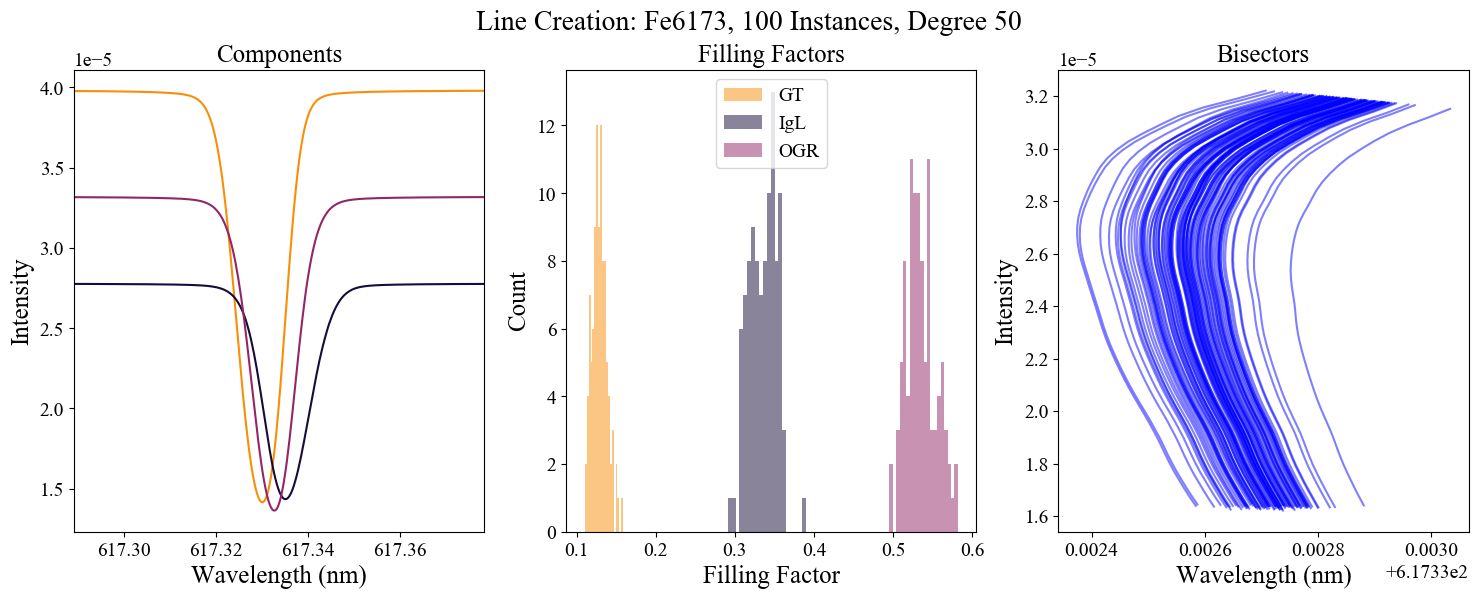

In [4]:
line = 'Fe6173'
lpg = LineProfileGenerator(line)
n_instances = 100
deg = 50

lpg.make_test_plot(deg, n_instances)

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.append('/home/astro/phrrdx/parameterisation')
sys.path.append('/home/astro/phrrdx/parameterisation/import_scripts/')
import get_data as gd
import line_profile_analysis as lpa
import bisector_analysis as ba

In [16]:
def get_BIS(bisector_wavelengths, bisector_fluxes, lower = [0.1, 0.4], upper = [0.55, 0.9]):
    #normalise the fluxes
    bisector_fluxes = (bisector_fluxes - np.min(bisector_fluxes)) / (np.max(bisector_fluxes) - np.min(bisector_fluxes))

    # 1. Bisector Wavelength Span (BWS) - traditional
    top_range = (bisector_fluxes > upper[0]) & (bisector_fluxes < upper[1])
    bottom_range = (bisector_fluxes > lower[0]) & (bisector_fluxes < lower[1])
    bws = np.mean(bisector_wavelengths[top_range]) - np.mean(bisector_wavelengths[bottom_range])

    return bws

/tmp/ipykernel_3709484/2085498880.py:25: ComplexWarning: Casting complex values to real discards the imaginary part
  RVs[i] = lpa.get_rv(wl, profs[i, :], template)
/tmp/ipykernel_3709484/2085498880.py:29: ComplexWarning: Casting complex values to real discards the imaginary part
  RVs_recon[i] = lpa.get_rv(wl, recon_profs[i], template)


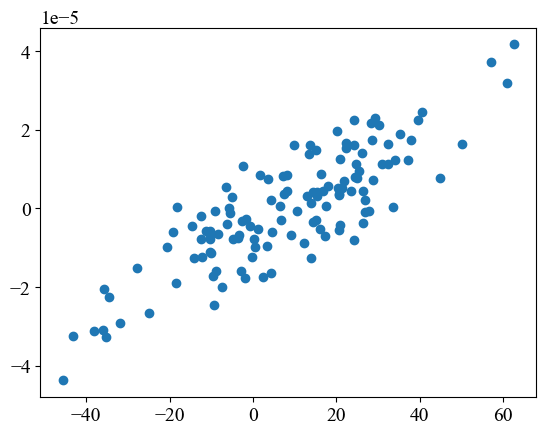

In [28]:
n_instances = 128
wl = gd.get_wl('HD', 'Fe6173')
deg = 10

profs = np.zeros((n_instances, len(wl)))

recon_profs = [gd.get_recon_profile('HD', 'Fe6173', 60, i) for i in range(n_instances)]


GT_quantiles = np.random.uniform(0, 1, n_instances)
ratio_quantiles = np.random.uniform(0, 1, n_instances)

template = gd.get_time_avg_flux('HD', 'Fe6173', 0)

BISs = np.zeros(n_instances)
RVs = np.zeros(n_instances)

BISs_recon = np.zeros(n_instances)
RVs_recon = np.zeros(n_instances)

for i in range(n_instances):
    profs[i, :] = lpg.get_full_profile(deg, GT_quantiles[i], ratio_quantiles[i])[0]
    bis, bisy = ba.calculate_line_bisector(wl, profs[i, :])
    BISs[i] = get_BIS(bis, bisy)
    RVs[i] = lpa.get_rv(wl, profs[i, :], template)

    bis_recon, bisy_recon = ba.calculate_line_bisector(wl, recon_profs[i])
    BISs_recon[i] = get_BIS(bis_recon, bisy_recon)
    RVs_recon[i] = lpa.get_rv(wl, recon_profs[i], template)

plt.plot(RVs, BISs - np.mean(BISs), 'o')
# plt.plot(RVs_recon, BISs_recon - np.mean(BISs_recon), 'o')





Calculating for degree 0.0 (1 of 20)


/tmp/ipykernel_3709484/1978335705.py:24: ComplexWarning: Casting complex values to real discards the imaginary part
  RVs[i] = lpa.get_rv(wl, profs[i, :], template)


Calculating for degree 3.9473684210526314 (2 of 20)
Calculating for degree 7.894736842105263 (3 of 20)
Calculating for degree 11.842105263157894 (4 of 20)
Calculating for degree 15.789473684210526 (5 of 20)
Calculating for degree 19.736842105263158 (6 of 20)
Calculating for degree 23.684210526315788 (7 of 20)
Calculating for degree 27.63157894736842 (8 of 20)
Calculating for degree 31.57894736842105 (9 of 20)
Calculating for degree 35.526315789473685 (10 of 20)
Calculating for degree 39.473684210526315 (11 of 20)
Calculating for degree 43.421052631578945 (12 of 20)
Calculating for degree 47.368421052631575 (13 of 20)
Calculating for degree 51.315789473684205 (14 of 20)
Calculating for degree 55.26315789473684 (15 of 20)
Calculating for degree 59.21052631578947 (16 of 20)
Calculating for degree 63.1578947368421 (17 of 20)
Calculating for degree 67.10526315789474 (18 of 20)
Calculating for degree 71.05263157894737 (19 of 20)
Calculating for degree 75.0 (20 of 20)


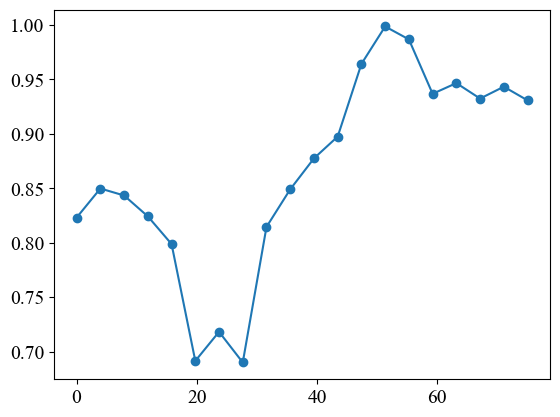

In [52]:
n_instances = 100
wl = gd.get_wl('HD', 'Fe6173')
degs = np.linspace(0, 75, 20)
Rs = np.zeros(len(degs))
slopes = np.zeros(len(degs))

template = gd.get_time_avg_flux('HD', 'Fe6173', 0)

for num, deg in enumerate(degs):
    print(f"Calculating for degree {deg} ({num+1} of {len(degs)})")

    profs = np.zeros((n_instances, len(wl)))

    GT_quantiles = np.random.uniform(0, 1, n_instances)
    ratio_quantiles = np.random.uniform(0, 1, n_instances)

    BISs = np.zeros(n_instances)
    RVs = np.zeros(n_instances)

    for i in range(n_instances):
        profs[i, :] = lpg.get_full_profile(deg, GT_quantiles[i], ratio_quantiles[i])[0]
        bis, bisy = ba.calculate_line_bisector(wl, profs[i, :])
        BISs[i] = get_BIS(bis, bisy)
        RVs[i] = lpa.get_rv(wl, profs[i, :], template)

    pearson_R = np.corrcoef(RVs, BISs)[0,1]
    Rs[num] = pearson_R

    slope = np.polyfit(RVs, BISs, 1)[0]
    slopes[num] = slope

plt.plot(degs, Rs, '-o')


Text(0, 0.5, 'Pearson R between RV and BIS')

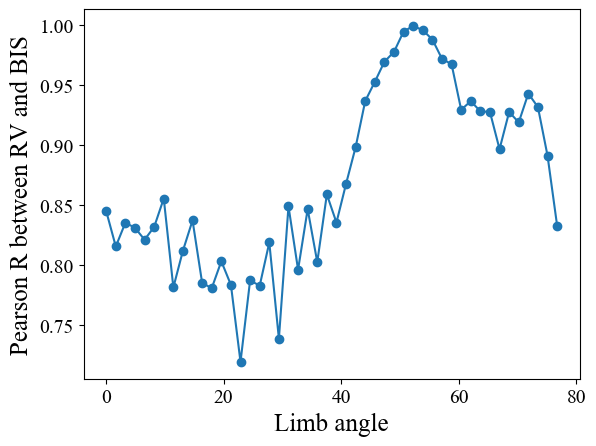

In [50]:
plt.plot(degs[0:48], Rs[0:48], '-o')
plt.xlabel('Limb angle')
plt.ylabel('Pearson R between RV and BIS')

/home/astro/phrrdx/.local/lib/python3.9/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/astro/phrrdx/.local/lib/python3.9/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


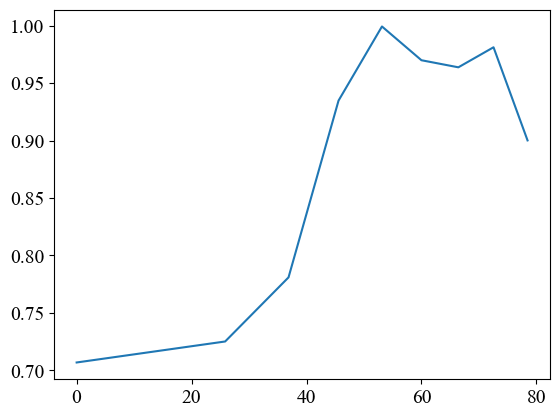

In [53]:
mus = [1.0, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2]
mu_strings = ['10', '09', '08', '07', '06', '05', '04', '03', '02']
mu_degs = np.arccos(mus)/np.pi*180

def get_recon_ts(mu_string):
    return np.load((f'/home/astro/phrrdx/MHD_workspace/results_HD_6173_mu{mu_string}/reconstructed_time_series.npy'))

Rs_validation = []
slopes_validation = []
for mu_string in mu_strings:
    recon_ts = get_recon_ts(mu_string)
    BISs_val = []
    RVs_val = []
    for i in range(recon_ts.shape[0]):
        prof = recon_ts[i, :]
        bis, bisy = ba.calculate_line_bisector(wl, prof)
        BISs_val.append(get_BIS(bis, bisy))
        RVs_val.append(lpa.get_rv(wl, prof, template))
    pearson_R_val = np.corrcoef(RVs_val, BISs_val)[0,1]
    Rs_validation.append(pearson_R_val)
    slope_val = np.polyfit(RVs_val, BISs_val, 1)[0]
    slopes_validation.append(slope_val)

plt.plot(mu_degs, Rs_validation)

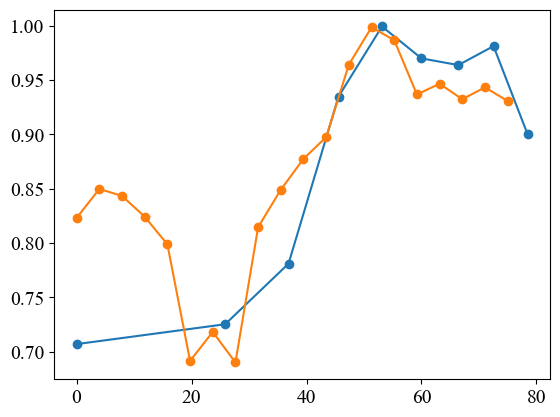

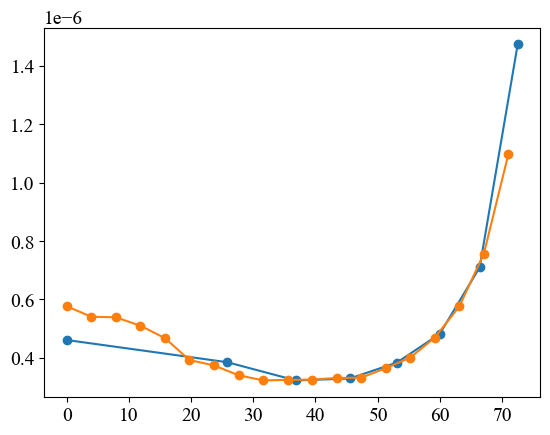

In [56]:
plt.plot(mu_degs, Rs_validation, '-o')
plt.plot(degs, Rs, '-o')
plt.show()

plt.plot(mu_degs[:-1], slopes_validation[:-1], '-o')
plt.plot(degs[:-1], slopes[:-1], '-o')